### ASSIGNMENT9-VB

In [10]:
# imports statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
sns.set(style="whitegrid")



In [11]:
# Getting the data knn_Classification_Data
df = pd.read_csv("advertising_dataset.csv",index_col=0)

Loading our dataset

In [12]:
#showing first 10 rows 
df.head(10)

,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Bought A Computer
Daily Time Spent on Site,,,,,,,,,
68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,3/27/2016 0:53,0
80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,4/4/2016 1:39,0
69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,3/13/2016 20:35,0
74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,1/10/2016 2:31,0
68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,6/3/2016 3:36,0
59.99,23,59761.56,226.74,Sharable client-driven software,Jamieberg,1,Norway,5/19/2016 14:30,0
88.91,33,53852.85,208.36,Enhanced dedicated support,Brandonstad,0,Myanmar,1/28/2016 20:59,0
66.00,48,24593.33,131.76,Reactive local challenge,Port Jefferybury,1,Australia,3/7/2016 1:40,1
74.53,30,68862.00,221.51,Configurable coherent function,West Colin,1,Grenada,4/18/2016 9:33,0


This shows the first 10 rows of the dataframe

## 1. EDA (Exploratory Data Analysis)

Shape: (1000, 9)

Column types:
 Age                       int64
Area Income             float64
Daily Internet Usage    float64
Ad Topic Line            object
City                     object
Male                      int64
Country                  object
Timestamp                object
Bought A Computer         int64
dtype: object

Missing values per column:
 Age                     0
Area Income             0
Daily Internet Usage    0
Ad Topic Line           0
City                    0
Male                    0
Country                 0
Timestamp               0
Bought A Computer       0
dtype: int64

Target counts:
 Bought A Computer
0    500
1    500
Name: count, dtype: int64


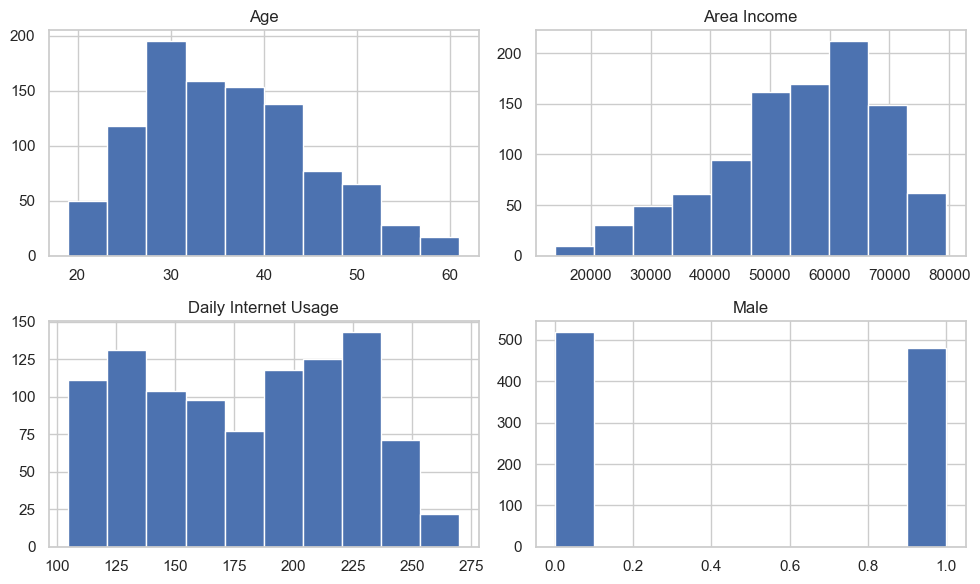

In [15]:
# Display the shape of the dataset (number of rows and columns)
print("Shape:", df.shape)
# Print data types of all columns to understand variable types (numeric, categorical, etc.)
print("\nColumn types:\n", df.dtypes)
# Show the number of missing values in each column to check data completeness
print("\nMissing values per column:\n", df.isna().sum())

# Display the frequency count of each class in the target variable 'Bought A Computer'
print("\nTarget counts:\n", df['Bought A Computer'].value_counts())

# Define a list of numeric columns for visualization
num_cols = ['Age', 'Area Income', 'Daily Internet Usage', 'Male']
# Plot histograms for numeric features to visualize their distributions
df[num_cols].hist(figsize=(10,6))
# Adjust layout for better spacing between subplots
plt.tight_layout()
# Display the histograms
plt.show()


This code explores the whole dataset by displaying the structure, data types, missing values, class distribution, and visualizing numeric feature distributions — This is the first step for EDA.

## Data Preprocessing


In [23]:
#showing the column
df.columns

Index(['Age', 'Area Income', 'Daily Internet Usage', 'Male',
       'Bought A Computer', 'hour', 'dayofweek'],
      dtype='object')

This gives us the list of all column names present in the dataset, It helps us in checking the available variables before selecting features or for further analysis.

In [18]:
# Displaying the values in the 'Male' column (1 = Male, 0 = Female)
df.Male

Daily Time Spent on Site
68.95    0
80.23    1
69.47    0
74.15    1
68.37    0
        ..
72.97    1
51.30    1
51.63    1
55.55    0
45.01    0
Name: Male, Length: 1000, dtype: int64

This shows the data in the "Male" column from the Dataset.  
this columns has binary values like "1" for male and "0" for female), representing the gender.

In [16]:
# Convert 'Male' to numeric if needed (already int64 here)
df['Male'] = df['Male'].astype(int)

# Convert 'Timestamp' to datetime and extract hour/day features
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['hour'] = df['Timestamp'].dt.hour.fillna(0).astype(int)
df['dayofweek'] = df['Timestamp'].dt.dayofweek.fillna(0).astype(int)

# Drop columns we won't use for simplicity in logistic regression
df = df.drop(['Ad Topic Line','City','Country','Timestamp'], axis=1)

# Check preprocessed data
df.head()


,Age,Area Income,Daily Internet Usage,Male,Bought A Computer,hour,dayofweek
Daily Time Spent on Site,,,,,,,
68.95,35,61833.90,256.09,0,0,0,6
80.23,31,68441.85,193.77,1,0,1,0
69.47,26,59785.94,236.50,0,0,20,6
74.15,29,54806.18,245.89,1,0,2,6
68.37,35,73889.99,225.58,0,0,3,4


The "Male" column was converted to numeric, and "Timestamp" column was transformed into "hour" and "dayofweek" features to capture temporal information. Unnecessary columns like"Ad Topic Line", "City", "Country", "Timestamp") were removed to make easy for the dataset for modeling. The first fist five rows were shown to check the changes.

### splitting data into X_train, X_test, y_train and y_test for modeling 

In [21]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('Bought A Computer', axis=1)
y = df['Bought A Computer']

# Train/test split (25% test set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())


X_train shape: (700, 6)
X_test shape: (300, 6)
y_train distribution:
 Bought A Computer
1    350
0    350
Name: count, dtype: int64


The dataset was divided into features "X" and target variable "y".  
A stratified train-test split was done, with 70% of data for training and 30% for testing (test_size=0.30) to makesure the target class distribution is preserved in both sets.  
We printed the shapes of the training and test sets while checking the distribution of the target variable in the training set.

### Fitting logistic regression model, train, test and evaluate model

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.94

Confusion Matrix:
 [[141   9]
 [  9 141]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94       150
           1       0.94      0.94      0.94       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



Numeric features were standardized using "StandardScaler" to makesure all variables contribute equally. A logistic regression model is then trained on the scaled training data to predict whether a customer buys a computer. The model is evaluated on the test set using accuracy, a confusion matrix, and a classification report showing precision, recall, and F1-score for each class so below are the values.

"Accuracy": The model correctly predicts 94% on the test set.  
"Confusion Matrix":  
  - True Negatives (0 predicted correctly): 141  
  - False Positives (0 predicted as 1): 9  
  - False Negatives (1 predicted as 0): 9  
  - True Positives (1 predicted correctly): 141  
This tells the model is balanced in predicting both classes.  
"Classification Report:
  - Precision: 94% for both classes, meaning when the model predicts a class, it is correct 94% of the time.  
  - Recall: 94% for both classes, indicating the model correctly identifies 94% of actual positives and negatives.  
  - F1-score: 0.94 for both classes, reflecting a strong balance between precision and recall.  
Overall, the logistic regression model performs very well and is equally effective at predicting both buyers and non-buyers.





